In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, roc_curve, precision_recall_curve,
                            accuracy_score, precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("=" * 60)
print("NOTEBOOK 3: CHURN PREDICTION")
print("=" * 60)

df_spark = spark.table("customer_churn_project.gold.mart_churn_risk")
df = df_spark.toPandas()

print(f"\nLoaded {len(df):,} customers from mart_churn_risk")
print(f"Columns: {list(df.columns)}")
print(f"\nChurn distribution:")
print(df['churn_label'].value_counts())
print(f"\nChurn rate: {df['churn_label'].mean():.1%}")
df.head()

NOTEBOOK 3: CHURN PREDICTION

Loaded 4,338 customers from mart_churn_risk
Columns: ['CustomerID', 'first_purchase_date', 'last_purchase_date', 'tenure_days', 'subscription_tier', 'monthly_fee', 'churn_label', 'country', 'is_uk_customer', 'total_transactions', 'total_spend', 'total_items', 'unique_products', 'avg_line_value', 'avg_order_value', 'recency_days', 'customer_lifespan_days', 'active_months', 'avg_items_per_order', 'has_high_value_order', 'has_bulk_purchase', 'spend_per_transaction', 'items_per_transaction', 'spend_per_product', 'purchase_regularity', 'tier_encoded', 'is_whale', 'is_inactive_90d', 'is_inactive_60d', 'engagement_score']

Churn distribution:
churn_label
0    2889
1    1449
Name: count, dtype: int64

Churn rate: 33.4%


,CustomerID,first_purchase_date,last_purchase_date,tenure_days,subscription_tier,monthly_fee,churn_label,country,is_uk_customer,total_transactions,total_spend,total_items,unique_products,avg_line_value,avg_order_value,recency_days,customer_lifespan_days,active_months,avg_items_per_order,has_high_value_order,has_bulk_purchase,spend_per_transaction,items_per_transaction,spend_per_product,purchase_regularity,tier_encoded,is_whale,is_inactive_90d,is_inactive_60d,engagement_score
0,13120,2011-04-15 10:19:00,2011-04-15 10:19:00,238,Basic,17.91,1,United Kingdom,True,1,30.60,12,1,30.60,30.60,238,0,1,1.00,0,0,30.60,12.00,30.60,None,1,False,True,True,0.79
1,15992,2011-12-06 11:00:00,2011-12-06 11:00:00,3,Basic,18.02,0,United Kingdom,True,1,41.99,17,3,14.00,41.99,3,0,1,3.00,0,0,41.99,17.00,14.00,None,1,False,False,False,1.23
2,13832,2011-11-20 15:36:00,2011-11-20 15:36:00,19,Basic,17.52,0,United Kingdom,True,1,52.20,28,3,17.40,52.20,18,0,1,3.00,0,0,52.20,28.00,17.40,None,1,False,False,False,1.26
3,16349,2011-02-22 12:40:00,2011-02-22 12:40:00,290,Basic,14.48,1,United Kingdom,True,1,53.50,9,9,5.94,53.50,290,0,1,9.00,0,0,53.50,9.00,5.94,None,1,False,True,True,2.46
4,13391,2011-05-20 10:50:00,2011-05-20 10:50:00,203,Basic,16.15,1,United Kingdom,True,1,59.80,4,1,59.80,59.80,203,0,1,1.00,0,0,59.80,4.00,59.80,None,1,False,True,True,0.88


In [0]:
print("=" * 60)
print("2. FEATURE ENGINEERING & SPLIT (FIXED — NO RECENCY LEAKAGE)")
print("=" * 60)

# REMOVED: recency_days (it's literally the churn definition)
# REMOVED: customer_lifespan_days (highly correlated with recency in this dataset)
# KEPT: Behavioral features that would be known BEFORE churn happens

feature_cols = [
    'total_transactions',
    'total_spend',
    'unique_products',
    'avg_order_value',
    'active_months',
    'avg_items_per_order',
    'has_high_value_order',
    'has_bulk_purchase',
    'spend_per_transaction',
    'items_per_transaction',
    'spend_per_product',
    'purchase_regularity',
    'tier_encoded',
    'engagement_score'
]

X = df[feature_cols].copy()
y = df['churn_label'].copy()

X = X.fillna(X.median())

print(f"Features selected: {len(feature_cols)} (removed recency_days to fix target leakage)")
print(f"Training samples: {len(X):,}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {len(X_train):,} ({y_train.mean():.1%} churn)")
print(f"Test set:  {len(X_test):,} ({y_test.mean():.1%} churn)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. FEATURE ENGINEERING & SPLIT (FIXED — NO RECENCY LEAKAGE)
Features selected: 14 (removed recency_days to fix target leakage)
Training samples: 4,338

Train set: 3,470 (33.4% churn)
Test set:  868 (33.4% churn)


In [0]:
print("=" * 60)
print("3. LOGISTIC REGRESSION (Primary Model)")
print("=" * 60)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("✅ Logistic Regression trained")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Active', 'Churned']))

print("\nMetrics:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lr):.3f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_lr):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.3f}")

# Cross-validation
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"\n5-Fold CV ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

3. LOGISTIC REGRESSION (Primary Model)
✅ Logistic Regression trained

Classification Report:
              precision    recall  f1-score   support

      Active       0.85      0.58      0.69       578
     Churned       0.49      0.80      0.61       290

    accuracy                           0.66       868
   macro avg       0.67      0.69      0.65       868
weighted avg       0.73      0.66      0.67       868


Metrics:
  Accuracy:  0.657
  Precision: 0.492
  Recall:    0.800
  F1 Score:  0.609
  ROC-AUC:   0.775

5-Fold CV ROC-AUC: 0.775 (+/- 0.036)


In [0]:
print("=" * 60)
print("4. RANDOM FOREST (Benchmark Model)")
print("=" * 60)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Active', 'Churned']))

print("\nMetrics:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf):.3f}")
print(f"  F1 Score:  {f1_score(y_test, y_pred_rf):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.3f}")

cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f"\n5-Fold CV ROC-AUC: {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std()*2:.3f})")

4. RANDOM FOREST (Benchmark Model)
✅ Random Forest trained

Classification Report:
              precision    recall  f1-score   support

      Active       0.84      0.67      0.75       578
     Churned       0.53      0.74      0.62       290

    accuracy                           0.69       868
   macro avg       0.68      0.71      0.68       868
weighted avg       0.74      0.69      0.70       868


Metrics:
  Accuracy:  0.695
  Precision: 0.531
  Recall:    0.741
  F1 Score:  0.619
  ROC-AUC:   0.781

5-Fold CV ROC-AUC: 0.783 (+/- 0.036)


5. MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.657      0.492   0.800     0.609    0.775
      Random Forest     0.695      0.531   0.741     0.619    0.781


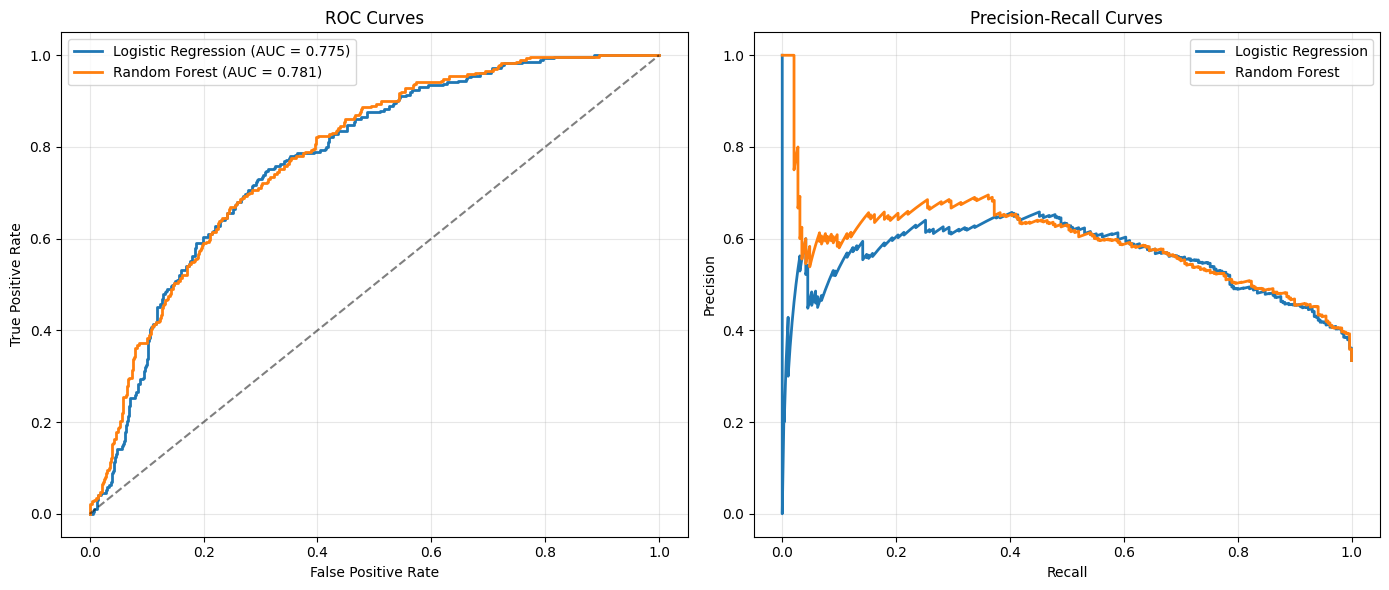


💾 Right-click → 'Save image as' → D:\Customer Churn Project\outputs\charts\churn_model_comparison.png


In [0]:
print("=" * 60)
print("5. MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
}).round(3)

print(comparison.to_string(index=False))

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})', linewidth=2)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

axes[1].plot(recall_lr, precision_lr, label='Logistic Regression', linewidth=2)
axes[1].plot(recall_rf, precision_rf, label='Random Forest', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
display(fig)

print("\n💾 Right-click → 'Save image as' → D:\\Customer Churn Project\\outputs\\charts\\churn_model_comparison.png")
plt.close()

6. FEATURE IMPORTANCE

Logistic Regression — Top 10 Drivers of Churn:
              Feature  Coefficient  Abs_Coefficient
        active_months    -1.207910         1.207910
      unique_products    -0.594482         0.594482
    spend_per_product     0.497914         0.497914
     engagement_score    -0.340515         0.340515
items_per_transaction    -0.267626         0.267626
   total_transactions    -0.118028         0.118028
          total_spend    -0.104881         0.104881
    has_bulk_purchase     0.087316         0.087316
         tier_encoded    -0.083974         0.083974
spend_per_transaction    -0.045519         0.045519

Random Forest — Top 10 Feature Importances:
              Feature  Importance
     engagement_score    0.150500
   total_transactions    0.150403
  purchase_regularity    0.121964
          total_spend    0.117832
        active_months    0.111352
      unique_products    0.086239
items_per_transaction    0.055439
spend_per_transaction    0.046246
      a

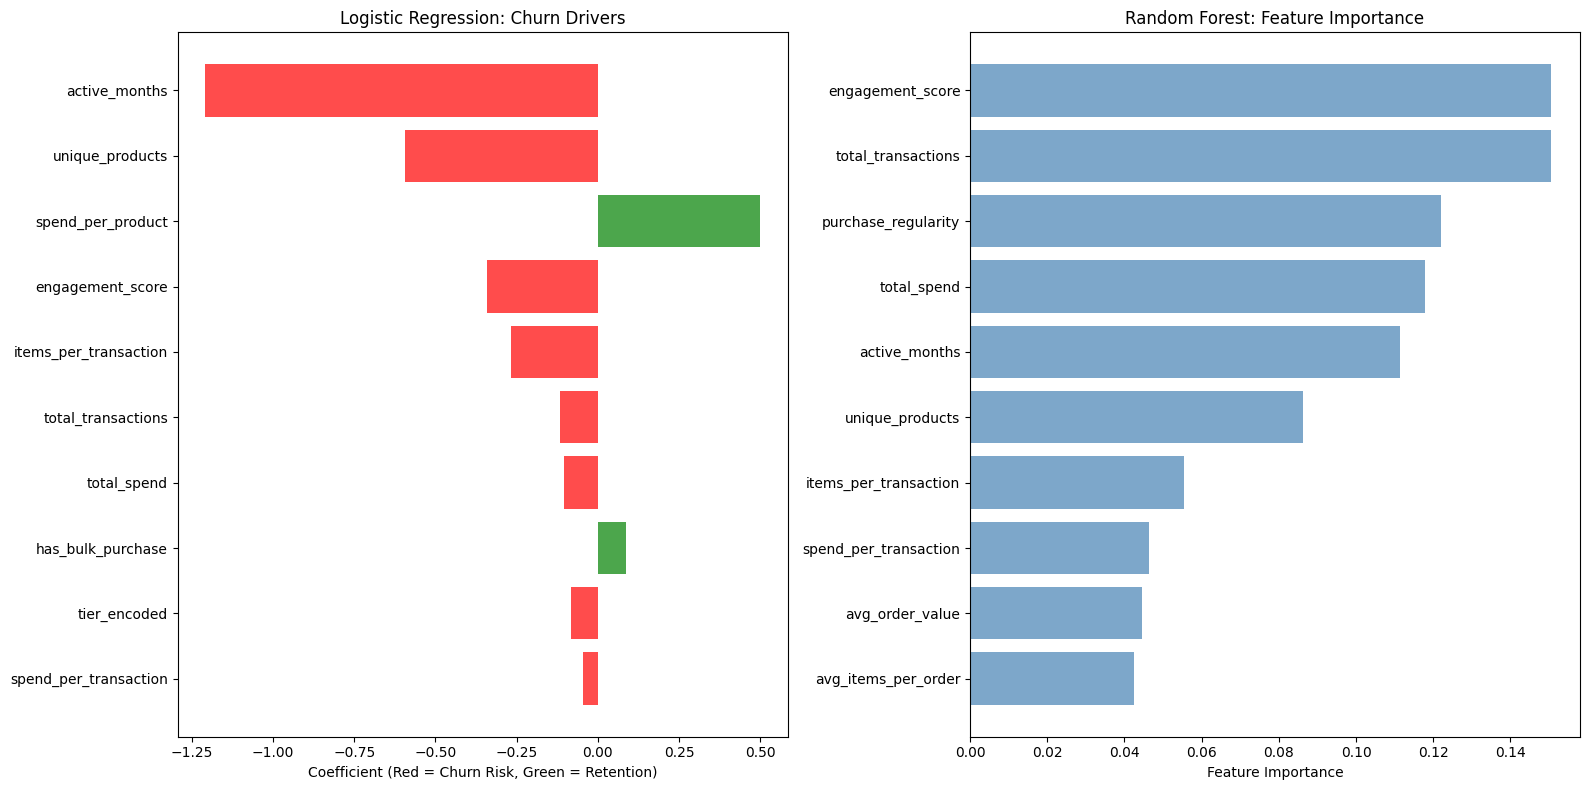


💾 Right-click → 'Save image as' → D:\Customer Churn Project\outputs\charts\churn_feature_importance.png


In [0]:
print("=" * 60)
print("6. FEATURE IMPORTANCE")
print("=" * 60)

# Logistic Regression coefficients
lr_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_[0],
    'Abs_Coefficient': np.abs(lr.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nLogistic Regression — Top 10 Drivers of Churn:")
print(lr_importance.head(10).to_string(index=False))

# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest — Top 10 Feature Importances:")
print(rf_importance.head(10).to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# LR coefficients
top_lr = lr_importance.head(10)
colors = ['red' if c < 0 else 'green' for c in top_lr['Coefficient']]
axes[0].barh(top_lr['Feature'], top_lr['Coefficient'], color=colors, alpha=0.7)
axes[0].set_xlabel('Coefficient (Red = Churn Risk, Green = Retention)')
axes[0].set_title('Logistic Regression: Churn Drivers')
axes[0].invert_yaxis()

# RF importance
top_rf = rf_importance.head(10)
axes[1].barh(top_rf['Feature'], top_rf['Importance'], color='steelblue', alpha=0.7)
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Random Forest: Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
display(fig)

print("\n💾 Right-click → 'Save image as' → D:\\Customer Churn Project\\outputs\\charts\\churn_feature_importance.png")
plt.close()

In [0]:
print("=" * 60)
print("7. BUSINESS RISK SCORING & SAVE")
print("=" * 60)

# Use Logistic Regression probabilities as churn risk score
df['churn_risk_score'] = lr.predict_proba(scaler.transform(X))[:, 1]

# Risk tiers
def risk_tier(score):
    if score >= 0.8:
        return 'Critical Risk (80%+)'
    elif score >= 0.6:
        return 'High Risk (60-80%)'
    elif score >= 0.4:
        return 'Medium Risk (40-60%)'
    elif score >= 0.2:
        return 'Low Risk (20-40%)'
    else:
        return 'Safe (<20%)'

df['risk_tier'] = df['churn_risk_score'].apply(risk_tier)

# Business summary
risk_summary = df.groupby('risk_tier').agg({
    'CustomerID': 'count',
    'total_spend': 'sum',
    'churn_risk_score': 'mean',
    'monthly_fee': 'sum'
}).round(2)

print("\n📊 Churn Risk Tier Summary:")
print(risk_summary)

# Save predictions back to Unity Catalog
df_spark_churn = spark.createDataFrame(df)
df_spark_churn.write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("customer_churn_project.gold.mart_churn_risk_scored")

print("\n✅ Saved to: customer_churn_project.gold.mart_churn_risk_scored")

# Executive summary
print("\n" + "=" * 60)
print("EXECUTIVE SUMMARY: CHURN PREDICTION")
print("=" * 60)

critical = df[df['risk_tier'] == 'Critical Risk (80%+)']
high = df[df['risk_tier'] == 'High Risk (60-80%)']

print(f"\n🚨 Critical Risk Customers: {len(critical):,} ({len(critical)/len(df):.1%})")
print(f"   Combined Historical Spend: £{critical['total_spend'].sum():,.2f}")
print(f"   Combined Monthly Fee: £{critical['monthly_fee'].sum():,.2f}/month")

print(f"\n⚠️  High Risk Customers: {len(high):,} ({len(high)/len(df):.1%})")
print(f"   Combined Historical Spend: £{high['total_spend'].sum():,.2f}")
print(f"   Combined Monthly Fee: £{high['monthly_fee'].sum():,.2f}/month")

print(f"\n📈 Model Performance:")
print(f"   Primary Model: Logistic Regression (ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f})")
print(f"   Benchmark: Random Forest (ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f})")
print(f"   Best Model: {'Logistic Regression' if roc_auc_score(y_test, y_prob_lr) >= roc_auc_score(y_test, y_prob_rf) else 'Random Forest'}")

print(f"\n💡 Recommended Action:")
print(f"   Target {len(critical) + len(high):,} at-risk customers with retention campaigns")
print(f"   Potential revenue at risk: £{(critical['monthly_fee'].sum() + high['monthly_fee'].sum()) * 12:,.2f}/year")

7. BUSINESS RISK SCORING & SAVE

📊 Churn Risk Tier Summary:
                      CustomerID  total_spend  churn_risk_score  monthly_fee
risk_tier                                                                   
Critical Risk (80%+)           7    123712.08              0.87       361.85
High Risk (60-80%)          1834    681066.49              0.70     34887.55
Low Risk (20-40%)            634   1146401.88              0.30     29033.31
Medium Risk (40-60%)         879    785136.26              0.51     27525.93
Safe (<20%)                  984   6150892.18              0.07     67752.26

✅ Saved to: customer_churn_project.gold.mart_churn_risk_scored

EXECUTIVE SUMMARY: CHURN PREDICTION

🚨 Critical Risk Customers: 7 (0.2%)
   Combined Historical Spend: £123,712.08
   Combined Monthly Fee: £361.85/month

⚠️  High Risk Customers: 1,834 (42.3%)
   Combined Historical Spend: £681,066.49
   Combined Monthly Fee: £34,887.55/month

📈 Model Performance:
   Primary Model: Logistic Regressio